Statistical analysis to view relationship between variables

In [ ]:
pip install -- pandas numpy scikit-learn  matplotlib seaborn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/My Drive/Data Science Projects/Sales_Forecast/Ml_train_sales_forecast_data (1).csv'
df = pd.read_csv(file_path)

print(df.head())


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1017209 non-null  float64
 12  CompetitionOpenSinceMonth  1017209 non-null  float64
 13  CompetitionO

In [ ]:
numeric_columns =['Sales','DayOfWeek','Date_year','CompetitionDistance', 'Open','CompetitionOpenSinceMonth','CompetitionOpenSinceYear', 'Promo1','Promo2']

In [ ]:
numeric_cols = [col for col in numeric_columns if col in df.columns]

Text(0.5, 1.0, 'Correlation Map')

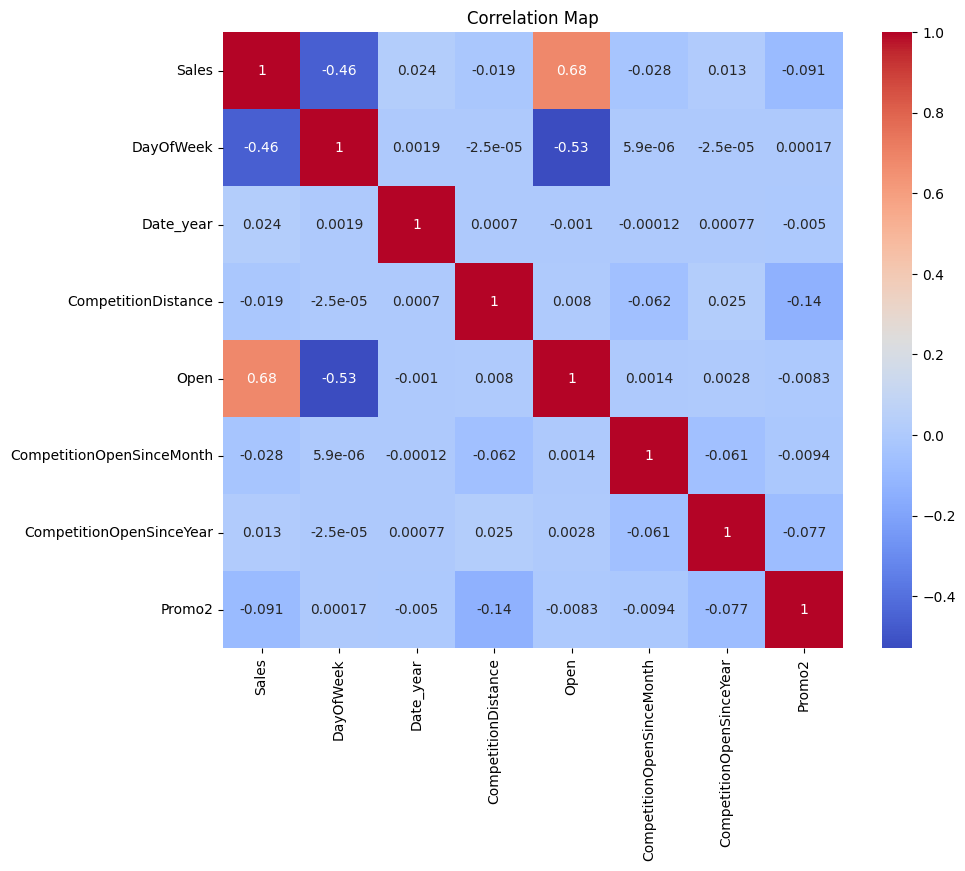

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_df = df[numeric_cols]
correlation_matrix = correlation_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Map')

In [ ]:
from statsmodels.stats.weightstats import ztest

# Separate sales data for 'Open' and 'Closed' stores
sales_open = df[df['Open'] == 1]['Sales']
sales_closed = df[df['Open'] == 0]['Sales']

# Perform two-sample z-test
# We assume unequal variances by default and test if means are different (value=0 for null hypothesis of no difference)
z_statistic, p_value = ztest(sales_open, sales_closed, value=0, alternative='two-sided')

print(f"Z-statistic for Sales (Open vs. Closed): {z_statistic:.4f}")
print(f"P-value for Sales (Open vs. Closed): {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print("There is a significant difference in mean Sales between open and closed stores.")
else:
    print(f"Since p-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print("There is no significant difference in mean Sales between open and closed stores.")

print(f"\nMean Sales when Open=1: {sales_open.mean():.2f}")
print(f"Mean Sales when Open=0: {sales_closed.mean():.2f}")

Z-statistic for Sales (Open vs. Closed): 931.4736
P-value for Sales (Open vs. Closed): 0.0000
Since p-value (0.0000) < alpha (0.05), we reject the null hypothesis.
There is a significant difference in mean Sales between open and closed stores.

Mean Sales when Open=1: 6955.51
Mean Sales when Open=0: 0.00


Z-Test